# 03. CNN Model Training for Driver Drowsiness Detection
**Driver Drowsiness Detection System**  
*Training a simplified Convolutional Neural Network (CNN).*

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


### 1. Load Preprocessed Data

In [2]:
data_path = "../dataset/preprocessed_data.npz"

if not os.path.exists(data_path):
    data_path = "dataset/preprocessed_data.npz"

data = np.load(data_path)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print("Data loaded successfully!")

Data loaded successfully!


### 2. Check Data Shapes

Train: (59574, 80, 80, 1) (59574,)
Validation: (13015, 80, 80, 1) (13015,)
Test: (12309, 80, 80, 1) (12309,)


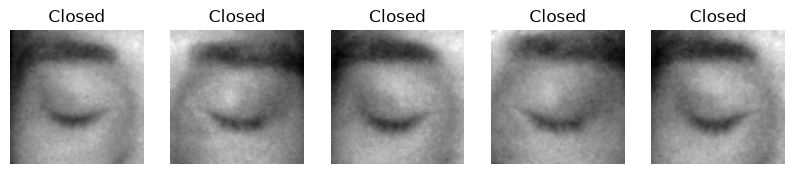

In [3]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title("Open" if y_train[i] == 1 else "Closed")
    plt.axis("off")

plt.show()

### 3. Build a Simple CNN Model

In [5]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Input(shape=(80, 80, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 78, 78, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,089 (2.35 MB)

 Trainable params: 617,089 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Compile the Model

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Model compiled.")

Model compiled.


### 5. Train the Model

In [7]:
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
931/931 ━━━━━━━━━━━━━━━━━━━━ 67s 70ms/step - accuracy: 0.9284 - loss: 0.1904 - val_accuracy: 0.9307 - val_loss: 0.1775
Epoch 2/10
931/931 ━━━━━━━━━━━━━━━━━━━━ 73s 78ms/step - accuracy: 0.9700 - loss: 0.0901 - val_accuracy: 0.9590 - val_loss: 0.1125
Epoch 3/10
931/931 ━━━━━━━━━━━━━━━━━━━━ 74s 79ms/step - accuracy: 0.9777 - loss: 0.0676 - val_accuracy: 0.9610 - val_loss: 0.1070
Epoch 4/10
931/931 ━━━━━━━━━━━━━━━━━━━━ 72s 77ms/step - accuracy: 0.9799 - loss: 0.0600 - val_accuracy: 0.9670 - val_loss: 0.1098
Epoch 5/10
931/931 ━━━━━━━━━━━━━━━━━━━━ 71s 76ms/step - accuracy: 0.9826 - loss: 0.0506 - val_accuracy: 0.9728 - val_loss: 0.0926
Epoch 6/10
931/931 ━━━━━━━━━━━━━━━━━━━━ 74s 79ms/step - accuracy: 0.9836 - loss: 0.0479 - val_accuracy: 0.9595 - val_loss: 0.1258
Epoch 7/10
931/931 ━━━━━━━━━━━━━━━━━━━━ 73s 78ms/step - accuracy: 0.9847 - loss: 0.0445 - val_accuracy: 0.9666 - val_loss: 0.1053
Epoch 8/10
931/931 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - accuracy: 0.9863 - loss: 0.0395 - 

### 6. Plot Training Curves

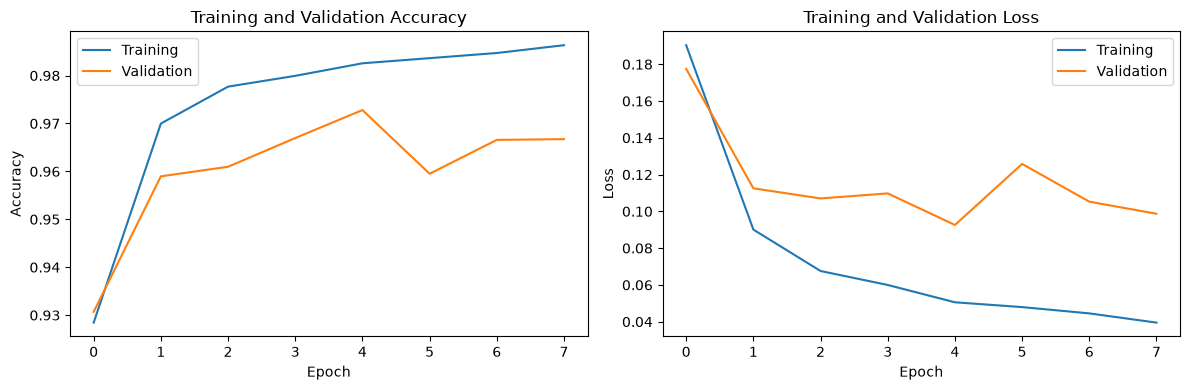

In [9]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### 7. Evaluate on Test Set

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = (model.predict(X_test) >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Closed (0)", "Open (1)"]))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Test Accuracy: 87.63%
385/385 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step

Classification Report:
              precision    recall  f1-score   support

  Closed (0)       0.96      0.78      0.86      6082
    Open (1)       0.82      0.97      0.89      6227

    accuracy                           0.88     12309
   macro avg       0.89      0.88      0.87     12309
weighted avg       0.89      0.88      0.88     12309


Confusion Matrix:
[[4744 1338]
 [ 185 6042]]


### 8. Save the Model

In [12]:
# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
model_path = "../models/drowsiness_cnn_model.keras"
model.save(model_path)

# Verify the saved model
print("Model saved successfully!")
print("Path:", model_path)
print("File size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

Model saved successfully!
Path: ../models/drowsiness_cnn_model.keras
File size: 7.11 MB
